# 05 — Multi-Elevation Beam Blockage and Radar Coverage
## ผลของ Elevation Angle ต่อ Terrain Blockage และ Radar Visibility

**Google Colab teaching notebook | Geography · Geoinformatics · Environmental Science · Radar Meteorology**

Notebook นี้ต่อจาก Notebook 00–04 และใช้แนวคิด **controlled experiment** โดยเปลี่ยนเฉพาะ elevation angle

$$
\theta
=
0.5^\circ,\;
1.0^\circ,\;
1.5^\circ,\;
2.0^\circ
$$

ขณะที่ radar site, DEM, beamwidth, $k$-factor, range geometry และ PBB/CBB algorithm คงเดิม

คำถามหลักคือ

> **การยก elevation angle ช่วยลด terrain blockage ได้มากเพียงใด และต้องแลกกับ beam altitude ที่สูงขึ้นเท่าใด?**

ในบทนี้เลือก **candidate ในอำเภอภูเพียง** จากชื่อสถานที่ใน metadata โดยตรง เพื่อป้องกันความสับสนหากรหัส A/B/C ถูกเปลี่ยนภายหลัง

### รูปแบบสมการสำหรับ Google Colab

Notebook นี้ใช้ `$ ... $` สำหรับสมการในบรรทัด และ `$$ ... $$` สำหรับสมการแยกบรรทัด เพื่อให้ MathJax แสดงผลได้เสถียรใน Google Colab

## 1. คำถามนำ

1. CBB จะลดลงทุกตำแหน่งเสมอหรือไม่เมื่อ elevation เพิ่ม?
2. elevation ที่สูงขึ้นช่วยลด terrain blockage เพราะเหตุใด?
3. หาก blockage ลดลงมาก แต่ beam สูงมากที่ระยะไกล จะมีผลต่อ QPE หรือ low-level detection อย่างไร?
4. D10 และ D50 เปลี่ยนอย่างไรตาม elevation?
5. เราควรสรุป coverage ด้วยจำนวน gates หรือพื้นที่จริง?
6. Minimum Usable Elevation (MUE) ให้สารสนเทศเพิ่มเติมจาก CBB map อย่างไร?

## 2. Learning Outcomes

เมื่อจบ Notebook นี้ นิสิตควรสามารถ

- คำนวณ PBB/CBB หลาย elevation angles ภายใต้ assumptions เดียวกัน
- อธิบาย trade-off ระหว่าง **terrain clearance** และ **beam sampling altitude**
- เปรียบเทียบ CBB maps ด้วย color scale เดียวกัน
- คำนวณ D10/D50 ครบ 360 azimuths
- สรุป blockage แบบ area-weighted ตาม range band
- สร้าง CBB difference maps
- สร้าง **Minimum Usable Elevation (MUE)**
- เตรียม outputs สำหรับ Notebook 06 ซึ่งจะเปรียบเทียบหลาย radar sites

# Part A — Elevation Trade-off

## 3. ทำไม Elevation ที่สูงขึ้นมักลด Blockage?

จาก beam-height equation

$$
h(r,\theta)
=
\sqrt{
r^2+(kR_e)^2+2rkR_e\sin\theta
}
-kR_e
$$

เมื่อ $\theta$ เพิ่ม ระดับ beam โดยทั่วไปจะสูงขึ้น ทำให้ระยะห่างระหว่างลำบีมกับภูมิประเทศเพิ่มขึ้น

$$
\theta\uparrow
\Rightarrow
H_{\mathrm{beam}}\uparrow
\Rightarrow
CBB\downarrow
$$

อย่างไรก็ตาม elevation สูงที่สุดไม่จำเป็นต้องดีที่สุด เพราะ beam อาจ sample precipitation สูงจากพื้นมากเกินไป โดยเฉพาะที่ระยะไกล

## 4. D10 และ D50

สำหรับแต่ละ azimuth $\alpha$

$$
D_{10}(\alpha)
=
\min
\left(
r:CBB(r,\alpha)\ge0.10
\right)
$$

$$
D_{50}(\alpha)
=
\min
\left(
r:CBB(r,\alpha)\ge0.50
\right)
$$

หาก threshold ไม่เกิดภายใน 240 km จะรายงานเป็น `NaN` ซึ่งหมายถึง **ไม่ถึง threshold ภายใน analysis range**

## 5. Area Weighting ของ Polar Gates

พื้นที่ของ radar gate ไม่เท่ากันตาม range

$$
A
=
\frac{1}{2}
\left(
r_2^2-r_1^2
\right)
\Delta\alpha
$$

สำหรับ 1° azimuth sampling

$$
\Delta\alpha
=
\frac{\pi}{180}
$$

ดังนั้น Notebook นี้จะไม่ใช้ gate count อย่างเดียว แต่เพิ่ม **area-weighted coverage statistics**

## 6. Minimum Usable Elevation (MUE)

ที่แต่ละ $(\alpha,r)$ เราหา elevation ต่ำที่สุดที่ทำให้

$$
CBB<0.10
$$

ตัวอย่าง

```text
0.5°  severe
1.0°  partial
1.5°  clear
2.0°  clear
```

ดังนั้น

$$
MUE=1.5^\circ
$$

MUE เป็น diagnostic สำหรับการสรุป radar visibility ไม่ใช่ค่าคงที่ทางฟิสิกส์

In [1]:
# ============================================================
# STEP 1 — Install required packages
# ============================================================

import sys
import subprocess
import importlib.util

required_packages = {
    "wradlib": "wradlib==2.9.5",
    "rasterio": "rasterio",
    "pyproj": "pyproj",
}

to_install = [
    pip_name
    for module_name, pip_name in required_packages.items()
    if importlib.util.find_spec(module_name) is None
]

if to_install:
    print("Installing:", to_install)
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q"] + to_install
    )

print("✓ Package check complete")

Installing: ['wradlib==2.9.5']
✓ Package check complete


In [2]:
# ============================================================
# STEP 2 — Imports and software environment
# ============================================================

from pathlib import Path
import json
import platform
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

import rasterio
from rasterio.transform import rowcol
from matplotlib.patches import Circle
from matplotlib.colors import TwoSlopeNorm
from pyproj import CRS

import wradlib as wrl

print("Software environment")
print("--------------------")
print("Python      :", platform.python_version())
print("wradlib     :", wrl.__version__)
print("NumPy       :", np.__version__)
print("Pandas      :", pd.__version__)
print("Matplotlib  :", mpl.__version__)
print("Rasterio    :", rasterio.__version__)

if wrl.__version__ != "2.9.5":
    print(
        "\n⚠ This notebook was developed and checked against "
        "wradlib 2.9.5."
    )

Software environment
--------------------
Python      : 3.13.15
wradlib     : 2.9.5
NumPy       : 2.1.3
Pandas      : 2.2.3
Matplotlib  : 3.10.0
Rasterio    : 1.5.1


In [3]:
# ============================================================
# STEP 3 — Mount Google Drive
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
# ============================================================
# STEP 4 — Paths and course-wide visual standards
# ============================================================

COURSE_ROOT = Path(
    "/content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage"
)

PROCESSED_DEM_DIR = COURSE_ROOT / "01_processed_data" / "dem"
METADATA_DIR = COURSE_ROOT / "02_metadata"
RESULTS_DIR = COURSE_ROOT / "03_results"
FIGURES_DIR = COURSE_ROOT / "04_figures"
TABLES_DIR = COURSE_ROOT / "05_tables"

for p in [METADATA_DIR, RESULTS_DIR, FIGURES_DIR, TABLES_DIR]:
    p.mkdir(parents=True, exist_ok=True)

DEM_PATH = (
    PROCESSED_DEM_DIR /
    "Nan_Radar_SRTM_DEM_1km_UTM47N_MAX.tif"
)

SITE_CSV = (
    METADATA_DIR /
    "01_site_elevation_native_vs_1km_MAX.csv"
)

GEOMETRY_JSON = (
    METADATA_DIR /
    "02_radar_beam_geometry_parameters.json"
)

DEM_CMAP = "terrain"
BLOCKAGE_CMAP = "PuRd"
BLOCKAGE_VMIN = 0.0
BLOCKAGE_VMAX = 1.0

CURRENT_MARKER = "*"
CURRENT_FACE = "darkorange"
CURRENT_EDGE = "black"

CANDIDATE_MARKER = "^"
CANDIDATE_FACE = "white"
CANDIDATE_EDGE = "black"

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "figure.dpi": 120,
    "savefig.dpi": 300,
})

print("DEM:", DEM_PATH)
print("Sites:", SITE_CSV)

DEM: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/01_processed_data/dem/Nan_Radar_SRTM_DEM_1km_UTM47N_MAX.tif
Sites: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/02_metadata/01_site_elevation_native_vs_1km_MAX.csv


# Part B — เลือก Primary Candidate Site

## 7. ใช้ชื่อสถานที่แทนการพึ่ง A/B/C

Notebook นี้ค้นหา site ที่มีคำว่า **Phu Phiang** ใน `site_name` แล้วอ่าน `site_id` จริงจาก metadata วิธีนี้ทำให้ workflow ผูกกับตำแหน่งจริง และลดความเสี่ยงจากการสลับรหัส candidate

In [5]:
# ============================================================
# STEP 5 — Dependency check and resolve Phu Phiang site
# ============================================================

checks = {
    "1-km DEM exists": DEM_PATH.exists(),
    "Radar-site metadata exists": SITE_CSV.exists(),
    "Beam-geometry metadata exists": GEOMETRY_JSON.exists(),
}

for label, ok in checks.items():
    print(("✓" if ok else "✗"), label)

if not all(checks.values()):
    raise RuntimeError(
        "Required outputs from Notebook 01–02 are missing."
    )

sites = pd.read_csv(SITE_CSV)

with open(GEOMETRY_JSON, "r", encoding="utf-8") as f:
    geometry = json.load(f)

PRIMARY_SITE_KEYWORD = "Phu Phiang"

match = sites[
    sites["site_name"].astype(str).str.contains(
        PRIMARY_SITE_KEYWORD,
        case=False,
        regex=False,
        na=False,
    )
].copy()

if len(match) != 1:
    raise ValueError(
        f"Expected exactly one site containing {PRIMARY_SITE_KEYWORD!r}, "
        f"but found {len(match)}."
    )

site = match.iloc[0]

FOCUS_SITE_ID = str(site["site_id"])
FOCUS_SITE_NAME = str(site["site_name"])

print("\nPrimary candidate selected by place name")
print("----------------------------------------")
print("Site ID   :", FOCUS_SITE_ID)
print("Site name :", FOCUS_SITE_NAME)
print("Ground    :", f"{float(site['native_dem_m']):.1f} m MSL")

✓ 1-km DEM exists
✓ Radar-site metadata exists
✓ Beam-geometry metadata exists

Primary candidate selected by place name
----------------------------------------
Site ID   : CAND_A
Site name : Tha Nao, Phu Phiang, Nan
Ground    : 235.0 m MSL


## 8. Controlled Experiment

เปลี่ยนเฉพาะ

$$
\theta
=
0.5^\circ,\;
1.0^\circ,\;
1.5^\circ,\;
2.0^\circ
$$

ส่วน DEM, beamwidth, $k$, range geometry, antenna-height assumption และ PBB/CBB algorithm คงเดิม

In [6]:
# ============================================================
# STEP 6 — Analysis configuration
# ============================================================

ELEVATIONS_DEG = np.array(
    [0.5, 1.0, 1.5, 2.0],
    dtype=float,
)

CLEAR_THRESHOLD = 0.10
SEVERE_THRESHOLD = 0.50

EARTH_RADIUS_M = float(geometry["earth_radius_m"])
K_STANDARD = float(geometry["k_standard"])

NRAYS = 360
NBINS = int(geometry["number_of_range_bins"])
RANGE_RES_M = float(geometry["range_resolution_m"])
MAX_RANGE_M = float(geometry["maximum_nominal_range_km"]) * 1000.0
BEAMWIDTH_DEG = float(geometry["beamwidth_deg"])
ANTENNA_AGL_M = float(
    geometry["antenna_agl_teaching_assumption_m"]
)

RADAR_LON = float(site["longitude"])
RADAR_LAT = float(site["latitude"])
RADAR_X_M = float(site["utm_x_m"])
RADAR_Y_M = float(site["utm_y_m"])
RADAR_GROUND_MSL_M = float(site["native_dem_m"])

RADAR_ALTITUDE_MSL_M = (
    RADAR_GROUND_MSL_M + ANTENNA_AGL_M
)

RANGE_CENTERS_M = (
    np.arange(NBINS, dtype=float) + 0.5
) * RANGE_RES_M

RANGE_EDGES_M = (
    np.arange(NBINS + 1, dtype=float)
    * RANGE_RES_M
)

RANGE_CENTERS_KM = RANGE_CENTERS_M / 1000.0
AZIMUTHS_DEG = np.arange(NRAYS, dtype=float)

print("Site            :", FOCUS_SITE_NAME)
print("Site ID         :", FOCUS_SITE_ID)
print("Elevations      :", ELEVATIONS_DEG)
print("Beamwidth       :", f"{BEAMWIDTH_DEG:.1f}°")
print("k-factor        :", f"{K_STANDARD:.6f}")
print("Max range       :", f"{MAX_RANGE_M/1000:.0f} km")
print("Antenna AGL     :", f"{ANTENNA_AGL_M:.1f} m")
print("Radar altitude  :", f"{RADAR_ALTITUDE_MSL_M:.1f} m MSL")

Site            : Tha Nao, Phu Phiang, Nan
Site ID         : CAND_A
Elevations      : [0.5 1.  1.5 2. ]
Beamwidth       : 1.0°
k-factor        : 1.333333
Max range       : 240 km
Antenna AGL     : 30.0 m
Radar altitude  : 265.0 m MSL


In [7]:
# ============================================================
# STEP 7 — Load DEM
# ============================================================

with rasterio.open(DEM_PATH) as ds:
    dem = ds.read(1, masked=True)
    dem_data = np.asarray(
        dem.filled(np.nan),
        dtype=np.float32,
    )
    dem_transform = ds.transform
    dem_crs = CRS.from_user_input(ds.crs)
    dem_bounds = ds.bounds
    dem_res = ds.res

print("DEM CRS       :", dem_crs)
print("DEM resolution:", dem_res)
print("DEM shape     :", dem.shape)

DEM CRS       : PROJCS["WGS 84 / UTM zone 47N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",99],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32647"]]
DEM resolution: (1000.0, 1000.0)
DEM shape     : (552, 529)


In [8]:
# ============================================================
# STEP 8 — Helper functions
# ============================================================

az2d = np.repeat(
    AZIMUTHS_DEG[:, None],
    NBINS,
    axis=1,
)

range2d = np.repeat(
    RANGE_CENTERS_M[None, :],
    NRAYS,
    axis=0,
)

beam_radius_m = np.asarray(
    wrl.util.half_power_radius(
        RANGE_CENTERS_M,
        BEAMWIDTH_DEG,
    ),
    dtype=np.float32,
)

beam_radius_2d = np.broadcast_to(
    beam_radius_m[None, :],
    (NRAYS, NBINS),
)

def sample_dem_at_xy(x_m, y_m):
    flat_x = np.asarray(x_m).ravel()
    flat_y = np.asarray(y_m).ravel()

    rows, cols = rowcol(
        dem_transform,
        flat_x,
        flat_y,
    )

    rows = np.asarray(rows, dtype=int)
    cols = np.asarray(cols, dtype=int)

    inside = (
        (rows >= 0)
        & (rows < dem_data.shape[0])
        & (cols >= 0)
        & (cols < dem_data.shape[1])
    )

    out = np.full(
        flat_x.shape,
        np.nan,
        dtype=np.float32,
    )

    out[inside] = dem_data[
        rows[inside],
        cols[inside],
    ]

    return out.reshape(np.asarray(x_m).shape)

def first_threshold_distance_km(values, threshold):
    idx = np.flatnonzero(
        np.isfinite(values)
        & (values >= threshold)
    )

    if idx.size == 0:
        return np.nan

    return float(
        RANGE_CENTERS_KM[idx[0]]
    )

def safe_id(text):
    return re.sub(
        r"[^A-Za-z0-9_\-]+",
        "_",
        str(text),
    ).strip("_")

SITE_TAG = safe_id(FOCUS_SITE_ID)

print("✓ Helper functions ready")

✓ Helper functions ready


# Part C — คำนวณ PBB/CBB ที่ 4 Elevations

สำหรับแต่ละ elevation:

1. สร้าง radar gate coordinates ด้วย `wradlib.georef.polar.spherical_to_proj`
2. sample 1-km MAX DEM
3. คำนวณ PBB ด้วย `wradlib.qual.beam_block_frac`
4. คำนวณ CBB ด้วย `wradlib.qual.cum_beam_block_frac`
5. เก็บ geometry และ blockage arrays เพื่อเปรียบเทียบต่อ

In [9]:
# ============================================================
# STEP 9 — Compute multi-elevation PBB/CBB
# ============================================================

multi = {}

for elev in ELEVATIONS_DEG:
    print(f"Processing elevation {elev:.1f}° ...")

    el2d = np.full(
        (NRAYS, NBINS),
        elev,
        dtype=float,
    )

    coords = wrl.georef.polar.spherical_to_proj(
        range2d,
        az2d,
        el2d,
        (
            RADAR_LON,
            RADAR_LAT,
            RADAR_ALTITUDE_MSL_M,
        ),
        crs=dem_crs,
        ke=K_STANDARD,
    )

    coords = np.asarray(coords, dtype=np.float64)

    x_m = coords[..., 0].astype(np.float32)
    y_m = coords[..., 1].astype(np.float32)
    beam_center_msl_m = coords[..., 2].astype(np.float32)

    terrain_msl_m = sample_dem_at_xy(
        x_m,
        y_m,
    )

    missing = ~np.isfinite(terrain_msl_m)

    terrain_calc = terrain_msl_m.copy()
    terrain_calc[missing] = -500.0

    with np.errstate(invalid="ignore", divide="ignore"):
        pbb = wrl.qual.beam_block_frac(
            terrain_calc,
            beam_center_msl_m,
            beam_radius_2d,
        )

    pbb = np.asarray(pbb, dtype=np.float32)
    pbb = np.clip(pbb, 0.0, 1.0)
    pbb[missing] = np.nan

    pbb_for_cbb = pbb.copy()
    pbb_for_cbb[~np.isfinite(pbb_for_cbb)] = 0.0

    cbb = wrl.qual.cum_beam_block_frac(
        pbb_for_cbb
    )

    cbb = np.asarray(cbb, dtype=np.float32)
    cbb[missing] = np.nan

    multi[float(elev)] = {
        "x_m": x_m,
        "y_m": y_m,
        "beam_center_msl_m": beam_center_msl_m,
        "terrain_msl_m": terrain_msl_m,
        "pbb": pbb,
        "cbb": cbb,
        "missing": missing,
    }

    print(
        "  valid terrain:",
        f"{100*(1-missing.mean()):.3f}%"
    )
    print(
        "  mean CBB     :",
        f"{np.nanmean(cbb):.3f}"
    )
    print(
        "  max CBB      :",
        f"{np.nanmax(cbb):.3f}"
    )

print("\n✓ Multi-elevation calculation complete")

Processing elevation 0.5° ...
  valid terrain: 100.000%
  mean CBB     : 0.813
  max CBB      : 1.000
Processing elevation 1.0° ...
  valid terrain: 100.000%
  mean CBB     : 0.579
  max CBB      : 1.000
Processing elevation 1.5° ...
  valid terrain: 100.000%
  mean CBB     : 0.366
  max CBB      : 1.000
Processing elevation 2.0° ...
  valid terrain: 100.000%
  mean CBB     : 0.152
  max CBB      : 0.991

✓ Multi-elevation calculation complete


In [10]:
# ============================================================
# STEP 10 — Numerical QC
# ============================================================

qc_rows = []

for elev in ELEVATIONS_DEG:
    item = multi[float(elev)]
    cbb = item["cbb"]
    pbb = item["pbb"]
    missing = item["missing"]

    complete_rays = ~missing.any(axis=1)

    monotonic = False
    if complete_rays.any():
        monotonic = bool(
            np.all(
                np.diff(
                    cbb[complete_rays, :],
                    axis=1,
                )
                >= -1e-7
            )
        )

    qc_rows.append({
        "elevation_deg": elev,
        "valid_terrain_pct": 100.0 * (1.0 - missing.mean()),
        "pbb_min": float(np.nanmin(pbb)),
        "pbb_max": float(np.nanmax(pbb)),
        "cbb_min": float(np.nanmin(cbb)),
        "cbb_max": float(np.nanmax(cbb)),
        "cbb_monotonic_complete_rays": monotonic,
    })

qc_table = pd.DataFrame(qc_rows)

display(
    qc_table.style.format({
        "elevation_deg": "{:.1f}",
        "valid_terrain_pct": "{:.3f}",
        "pbb_min": "{:.3f}",
        "pbb_max": "{:.3f}",
        "cbb_min": "{:.3f}",
        "cbb_max": "{:.3f}",
    })
)

,elevation_deg,valid_terrain_pct,pbb_min,pbb_max,cbb_min,cbb_max,cbb_monotonic_complete_rays
0,0.5,100.000,0.000,1.000,0.000,1.000,True
1,1.0,100.000,0.000,1.000,0.000,1.000,True
2,1.5,100.000,0.000,1.000,0.000,1.000,True
3,2.0,100.000,0.000,0.991,0.000,0.991,True


# Part D — Cartographic Context

## 9. Figure 1 — Primary Phu Phiang Candidate

มาตรฐานแผนที่:

- DEM = `terrain`
- Current radar = ดาวสีส้ม ขอบดำ
- Candidate = สามเหลี่ยมสีขาว ขอบดำ
- Primary Phu Phiang candidate = marker ใหญ่และขอบหนากว่า
- ใช้ manual label offsets เพื่อป้องกันข้อความซ้อนกัน

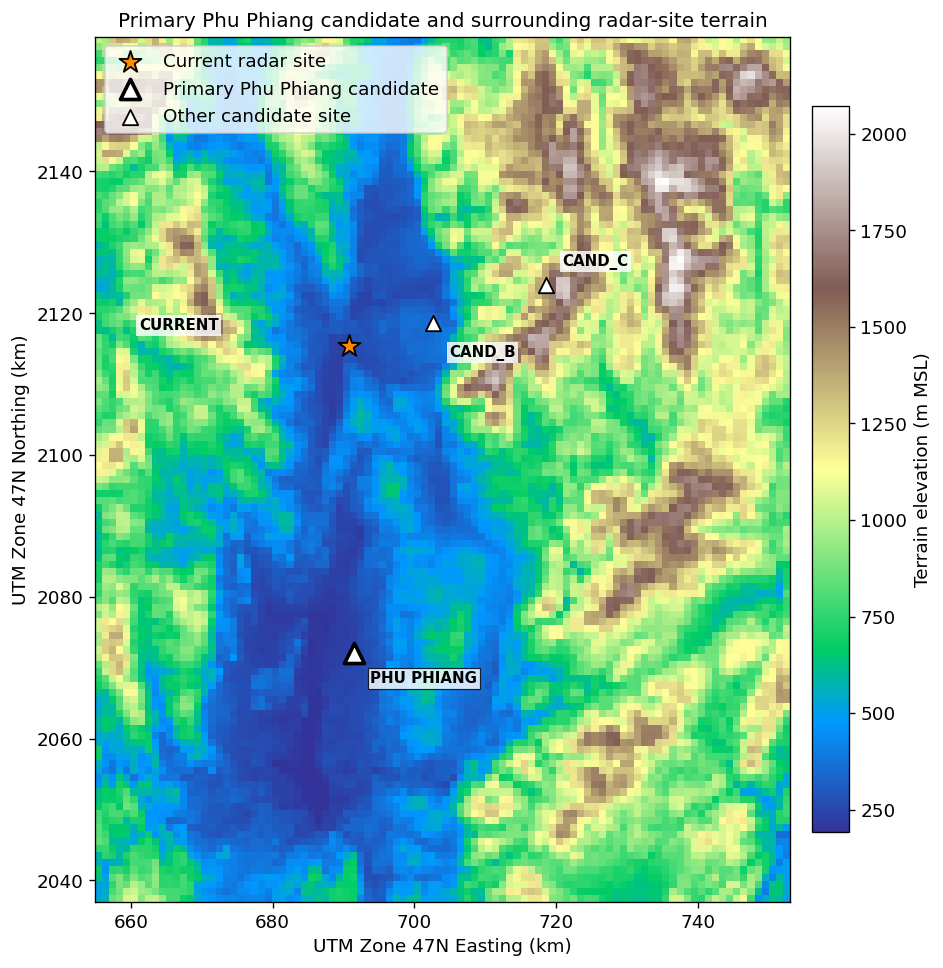

Saved: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/04_figures/Fig05_01_PhuPhiang_Primary_Candidate_Local_Terrain.png


In [11]:
# ============================================================
# STEP 11 — Figure 1: local terrain and site context
# ============================================================

local_buffer_m = 35_000.0

local_xmin = sites["utm_x_m"].min() - local_buffer_m
local_xmax = sites["utm_x_m"].max() + local_buffer_m
local_ymin = sites["utm_y_m"].min() - local_buffer_m
local_ymax = sites["utm_y_m"].max() + local_buffer_m

with rasterio.open(DEM_PATH) as ds:
    local_window = (
        rasterio.windows
        .from_bounds(
            local_xmin,
            local_ymin,
            local_xmax,
            local_ymax,
            transform=ds.transform,
        )
        .round_offsets()
        .round_lengths()
    )

    local_dem = ds.read(
        1,
        window=local_window,
        masked=True,
    )

    local_bounds = rasterio.windows.bounds(
        local_window,
        ds.transform,
    )

local_extent_km = [
    local_bounds[0] / 1000.0,
    local_bounds[2] / 1000.0,
    local_bounds[1] / 1000.0,
    local_bounds[3] / 1000.0,
]

label_offsets = {
    "CURRENT": (-78, 12),
    "CAND_A": (10, -15),
    "CAND_B": (10, -18),
    "CAND_C": (10, 14),
}

fig, ax = plt.subplots(figsize=(9.5, 8.2))

im = ax.imshow(
    local_dem,
    cmap=DEM_CMAP,
    extent=local_extent_km,
    origin="upper",
)

for _, row in sites.iterrows():
    x_km = float(row["utm_x_m"]) / 1000.0
    y_km = float(row["utm_y_m"]) / 1000.0
    is_focus = str(row["site_id"]) == FOCUS_SITE_ID

    if row["status"] == "Existing":
        ax.scatter(
            x_km,
            y_km,
            marker=CURRENT_MARKER,
            s=190,
            facecolor=CURRENT_FACE,
            edgecolor=CURRENT_EDGE,
            linewidth=1.1,
            zorder=8,
            label="Current radar site",
        )
    else:
        ax.scatter(
            x_km,
            y_km,
            marker=CANDIDATE_MARKER,
            s=145 if is_focus else 85,
            facecolor=CANDIDATE_FACE,
            edgecolor=CANDIDATE_EDGE,
            linewidth=2.2 if is_focus else 1.1,
            zorder=8,
            label=(
                "Primary Phu Phiang candidate"
                if is_focus
                else "Other candidate site"
            ),
        )

    dx, dy = label_offsets.get(
        str(row["site_id"]),
        (8, 8),
    )

    label_text = (
        "PHU PHIANG"
        if is_focus
        else str(row["site_id"])
    )

    ax.annotate(
        label_text,
        xy=(x_km, y_km),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=9,
        fontweight="bold",
        ha="left" if dx >= 0 else "right",
        va="center",
        bbox={
            "facecolor": "white",
            "edgecolor": "black" if is_focus else "none",
            "linewidth": 0.7,
            "alpha": 0.82,
            "pad": 1.5,
        },
        zorder=9,
    )

handles, labels = ax.get_legend_handles_labels()
unique = {}
for h, label in zip(handles, labels):
    if label not in unique:
        unique[label] = h

ax.legend(
    unique.values(),
    unique.keys(),
    loc="upper left",
)

cbar = fig.colorbar(
    im,
    ax=ax,
    shrink=0.84,
    pad=0.02,
)
cbar.set_label("Terrain elevation (m MSL)")

ax.set_xlabel("UTM Zone 47N Easting (km)")
ax.set_ylabel("UTM Zone 47N Northing (km)")
ax.set_title(
    "Primary Phu Phiang candidate and surrounding radar-site terrain"
)
ax.set_aspect("equal", adjustable="box")

fig.tight_layout()

fig1_path = (
    FIGURES_DIR /
    "Fig05_01_PhuPhiang_Primary_Candidate_Local_Terrain.png"
)

fig.savefig(
    fig1_path,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print("Saved:", fig1_path)

# Part E — CBB Maps ที่ 4 Elevations

## 10. Figures 2–5

ทุก CBB map ใช้

```python
cmap="PuRd"
vmin=0
vmax=1
```

เพื่อให้สีมีความหมายเหมือนกันทุก elevation และสามารถเปรียบเทียบกันโดยตรง

/tmp/ipykernel_624/3877938048.py:15: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  m = ax.pcolormesh(


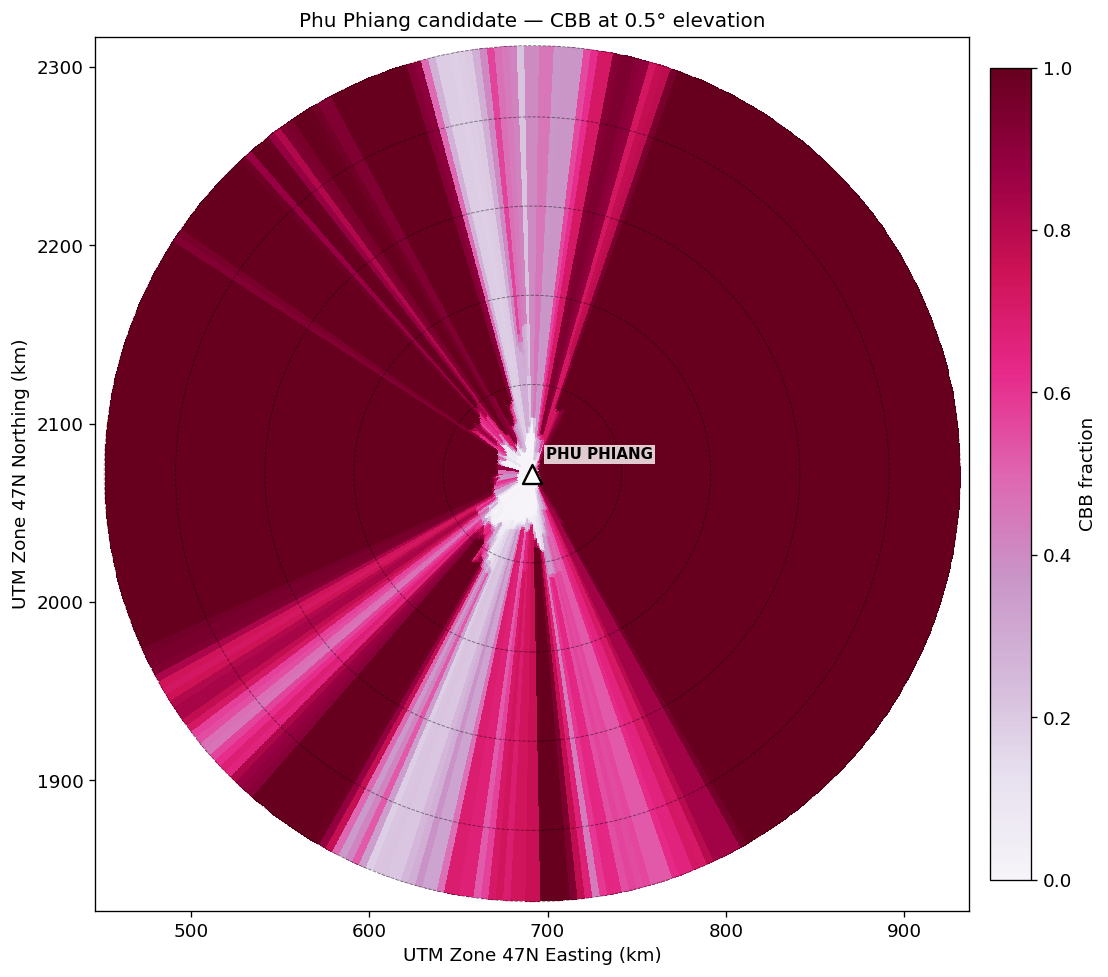

Saved: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/04_figures/Fig05_02_PhuPhiang_CBB_0p5deg.png


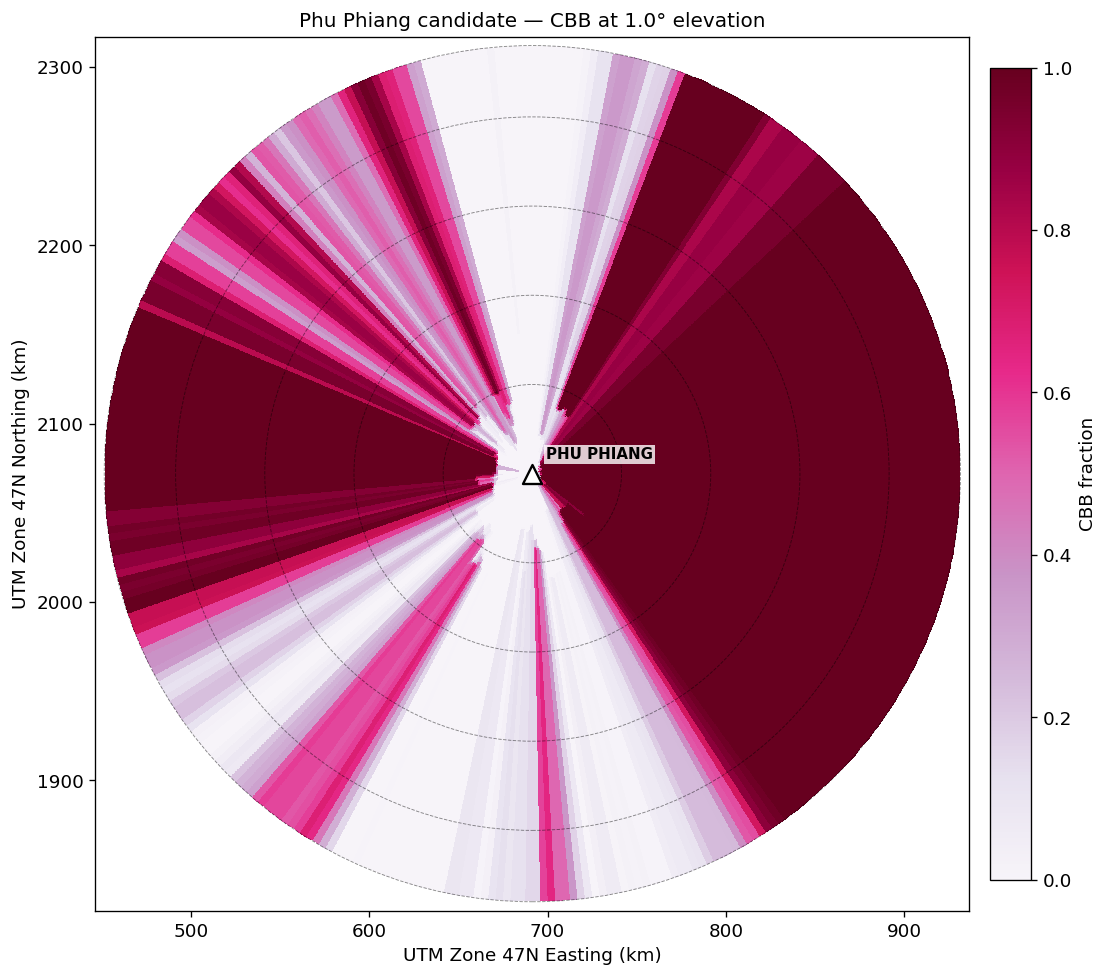

Saved: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/04_figures/Fig05_03_PhuPhiang_CBB_1p0deg.png


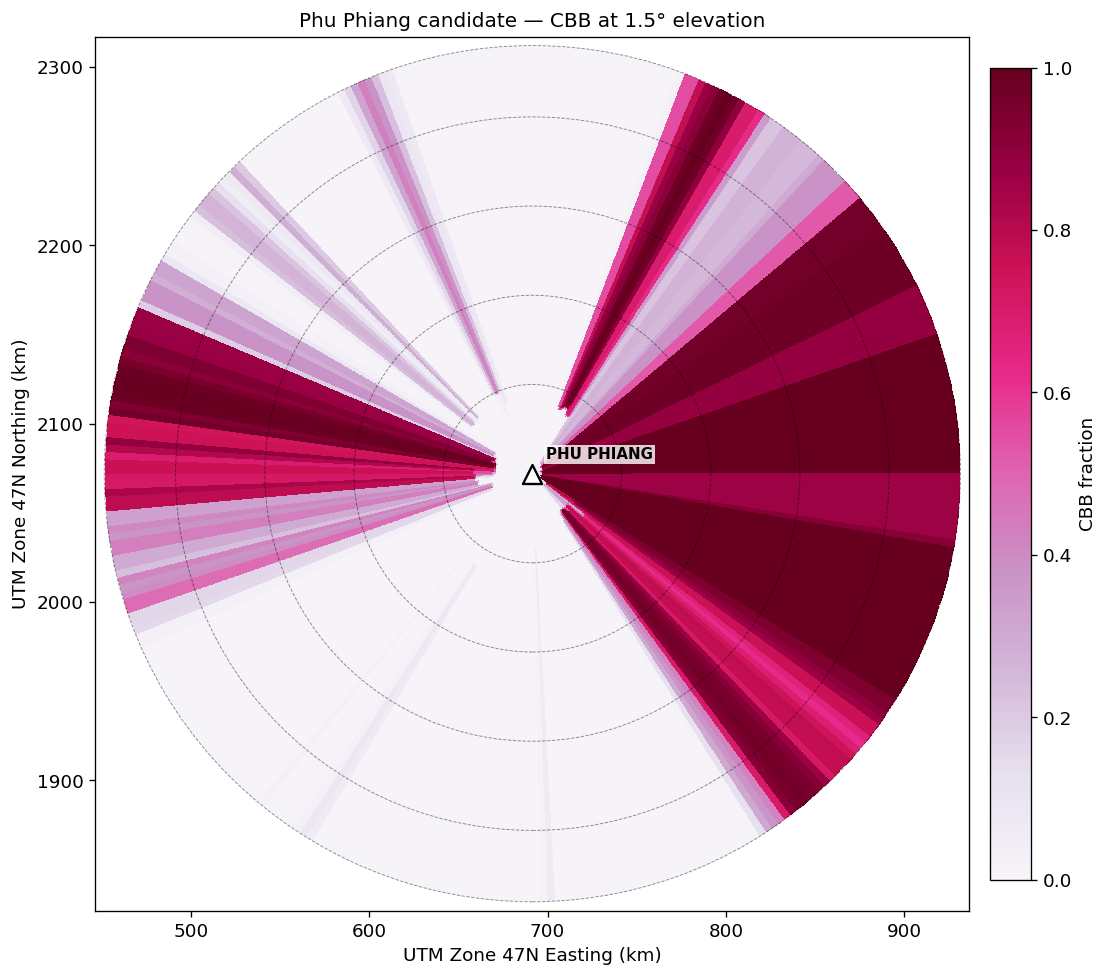

Saved: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/04_figures/Fig05_04_PhuPhiang_CBB_1p5deg.png


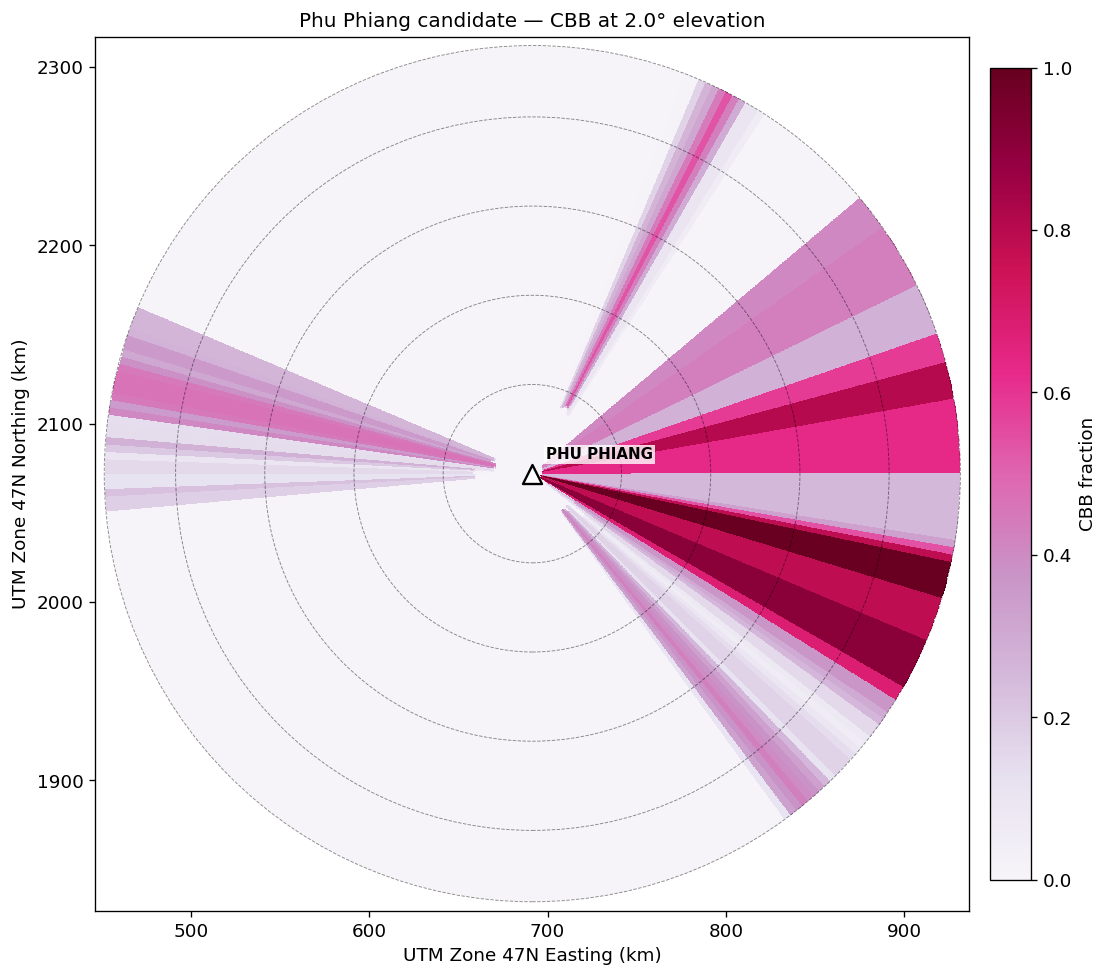

Saved: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/04_figures/Fig05_05_PhuPhiang_CBB_2p0deg.png


In [12]:
# ============================================================
# STEP 12 — Figures 2–5: CBB maps
# ============================================================

map_paths = []

site_x_km = RADAR_X_M / 1000.0
site_y_km = RADAR_Y_M / 1000.0

for fig_number, elev in enumerate(ELEVATIONS_DEG, start=2):
    item = multi[float(elev)]

    fig, ax = plt.subplots(figsize=(9.8, 8.8))

    m = ax.pcolormesh(
        item["x_m"] / 1000.0,
        item["y_m"] / 1000.0,
        item["cbb"],
        cmap=BLOCKAGE_CMAP,
        vmin=BLOCKAGE_VMIN,
        vmax=BLOCKAGE_VMAX,
        shading="auto",
    )

    for rr in [50, 100, 150, 200, 240]:
        ax.add_patch(
            Circle(
                (site_x_km, site_y_km),
                rr,
                fill=False,
                linestyle="--",
                linewidth=0.55,
                edgecolor="black",
                alpha=0.45,
            )
        )

    ax.scatter(
        site_x_km,
        site_y_km,
        marker=CANDIDATE_MARKER,
        s=130,
        facecolor=CANDIDATE_FACE,
        edgecolor=CANDIDATE_EDGE,
        linewidth=1.4,
        zorder=7,
    )

    ax.annotate(
        "PHU PHIANG",
        (site_x_km, site_y_km),
        xytext=(8, 9),
        textcoords="offset points",
        fontsize=9,
        fontweight="bold",
        bbox={
            "facecolor": "white",
            "edgecolor": "none",
            "alpha": 0.80,
            "pad": 1.3,
        },
    )

    ax.set_xlim(site_x_km - 245, site_x_km + 245)
    ax.set_ylim(site_y_km - 245, site_y_km + 245)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("UTM Zone 47N Easting (km)")
    ax.set_ylabel("UTM Zone 47N Northing (km)")
    ax.set_title(
        f"Phu Phiang candidate — CBB at {elev:.1f}° elevation"
    )

    cbar = fig.colorbar(
        m,
        ax=ax,
        shrink=0.82,
        pad=0.02,
    )
    cbar.set_label("CBB fraction")

    fig.tight_layout()

    elev_tag = str(elev).replace(".", "p")
    path = (
        FIGURES_DIR /
        f"Fig05_{fig_number:02d}_PhuPhiang_CBB_{elev_tag}deg.png"
    )

    fig.savefig(
        path,
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

    map_paths.append(str(path))
    print("Saved:", path)

# Part F — Beam Altitude Trade-off

## 11. Figure 6

กราฟนี้เปรียบเทียบ beam-centre altitude ของทั้ง 4 elevation angles เพื่อให้เห็นว่าการลด terrain blockage มีต้นทุนด้าน vertical sampling อย่างไร

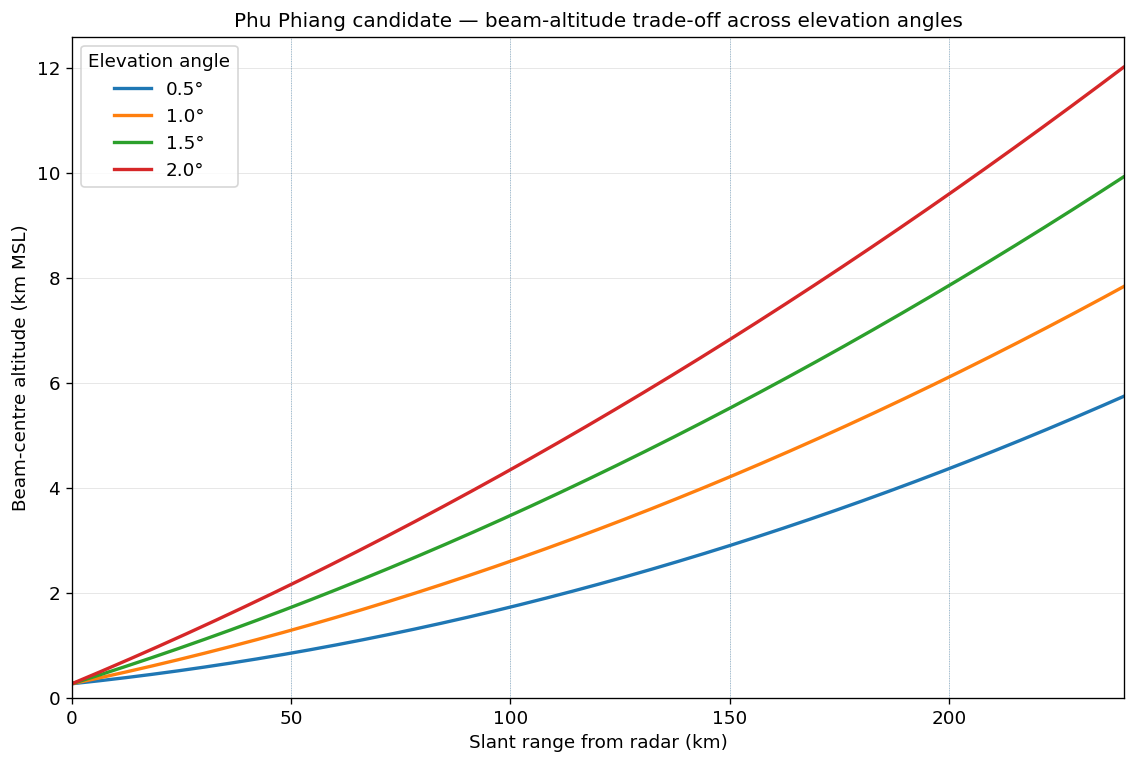

Saved: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/04_figures/Fig05_06_PhuPhiang_Beam_Altitude_Tradeoff.png


In [13]:
# ============================================================
# STEP 13 — Figure 6: beam altitude trade-off
# ============================================================

fig, ax = plt.subplots(figsize=(9.6, 6.5))

for elev in ELEVATIONS_DEG:
    beam_msl = multi[float(elev)]["beam_center_msl_m"][0, :]

    ax.plot(
        RANGE_CENTERS_KM,
        beam_msl / 1000.0,
        linewidth=2.0,
        label=f"{elev:.1f}°",
    )

for rr in [50, 100, 150, 200, 240]:
    ax.axvline(
        rr,
        linewidth=0.55,
        linestyle=":",
        alpha=0.45,
    )

ax.set_xlim(0, 240)
ax.set_ylim(bottom=0)
ax.set_xlabel("Slant range from radar (km)")
ax.set_ylabel("Beam-centre altitude (km MSL)")
ax.set_title(
    "Phu Phiang candidate — beam-altitude trade-off across elevation angles"
)
ax.grid(True, linewidth=0.4, alpha=0.45)
ax.legend(title="Elevation angle", loc="upper left")

fig.tight_layout()

fig6_path = (
    FIGURES_DIR /
    "Fig05_06_PhuPhiang_Beam_Altitude_Tradeoff.png"
)

fig.savefig(
    fig6_path,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print("Saved:", fig6_path)

In [14]:
# ============================================================
# STEP 14 — Beam altitude table at selected ranges
# ============================================================

selected_ranges_km = [50, 100, 150, 200, 240]

rows = []

for elev in ELEVATIONS_DEG:
    beam_msl = multi[float(elev)]["beam_center_msl_m"][0, :]

    for target_km in selected_ranges_km:
        idx = int(
            np.argmin(
                np.abs(RANGE_CENTERS_KM - target_km)
            )
        )

        rows.append({
            "elevation_deg": elev,
            "target_range_km": target_km,
            "actual_gate_range_km": RANGE_CENTERS_KM[idx],
            "beam_center_altitude_msl_m": float(beam_msl[idx]),
        })

beam_altitude_table = pd.DataFrame(rows)

display(
    beam_altitude_table.style.format({
        "elevation_deg": "{:.1f}",
        "target_range_km": "{:.0f}",
        "actual_gate_range_km": "{:.2f}",
        "beam_center_altitude_msl_m": "{:.1f}",
    })
)

beam_altitude_csv = (
    TABLES_DIR /
    "05_PhuPhiang_Beam_Altitude_Selected_Ranges.csv"
)

beam_altitude_table.to_csv(
    beam_altitude_csv,
    index=False,
)

print("\nSaved:")
print(beam_altitude_csv)

,elevation_deg,target_range_km,actual_gate_range_km,beam_center_altitude_msl_m
0,0.5,50,49.75,844.7
1,0.5,100,99.75,1720.5
2,0.5,150,149.75,2890.3
3,0.5,200,199.75,4353.8
4,0.5,240,239.75,5736.0
5,1.0,50,49.75,1278.8
6,1.0,100,99.75,2590.8
7,1.0,150,149.75,4196.5
8,1.0,200,199.75,6095.8
9,1.0,240,239.75,7826.4



Saved:
/content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/05_tables/05_PhuPhiang_Beam_Altitude_Selected_Ranges.csv


# Part G — D10 และ D50 ครบ 360°

## 12. Directional Threshold Distances

D10/D50 ช่วยตอบคำถามว่า blockage เริ่มมีนัยสำคัญ **ที่ระยะใด** มากกว่าดู maximum CBB เพียงอย่างเดียว

In [15]:
# ============================================================
# STEP 15 — Compute D10 and D50 for every azimuth
# ============================================================

threshold_rows = []

for elev in ELEVATIONS_DEG:
    cbb = multi[float(elev)]["cbb"]

    for az in AZIMUTHS_DEG:
        ray = cbb[int(az), :]

        threshold_rows.append({
            "site_id": FOCUS_SITE_ID,
            "site_name": FOCUS_SITE_NAME,
            "elevation_deg": elev,
            "azimuth_deg": az,
            "D10_km": first_threshold_distance_km(
                ray,
                CLEAR_THRESHOLD,
            ),
            "D50_km": first_threshold_distance_km(
                ray,
                SEVERE_THRESHOLD,
            ),
        })

threshold_table = pd.DataFrame(threshold_rows)

threshold_csv = (
    TABLES_DIR /
    "05_PhuPhiang_D10_D50_All_Azimuths.csv"
)

threshold_table.to_csv(
    threshold_csv,
    index=False,
)

print("Saved:", threshold_csv)
display(threshold_table.head(12))

Saved: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/05_tables/05_PhuPhiang_D10_D50_All_Azimuths.csv


,site_id,site_name,elevation_deg,azimuth_deg,D10_km,D50_km
0,CAND_A,"Tha Nao, Phu Phiang, Nan",0.5,0.0,28.25,NaN
1,CAND_A,"Tha Nao, Phu Phiang, Nan",0.5,1.0,28.25,NaN
2,CAND_A,"Tha Nao, Phu Phiang, Nan",0.5,2.0,23.25,NaN
3,CAND_A,"Tha Nao, Phu Phiang, Nan",0.5,3.0,22.25,NaN
4,CAND_A,"Tha Nao, Phu Phiang, Nan",0.5,4.0,22.25,NaN
5,CAND_A,"Tha Nao, Phu Phiang, Nan",0.5,5.0,7.25,NaN
6,CAND_A,"Tha Nao, Phu Phiang, Nan",0.5,6.0,7.25,NaN
7,CAND_A,"Tha Nao, Phu Phiang, Nan",0.5,7.0,7.25,NaN
8,CAND_A,"Tha Nao, Phu Phiang, Nan",0.5,8.0,7.25,21.25
9,CAND_A,"Tha Nao, Phu Phiang, Nan",0.5,9.0,7.25,21.25


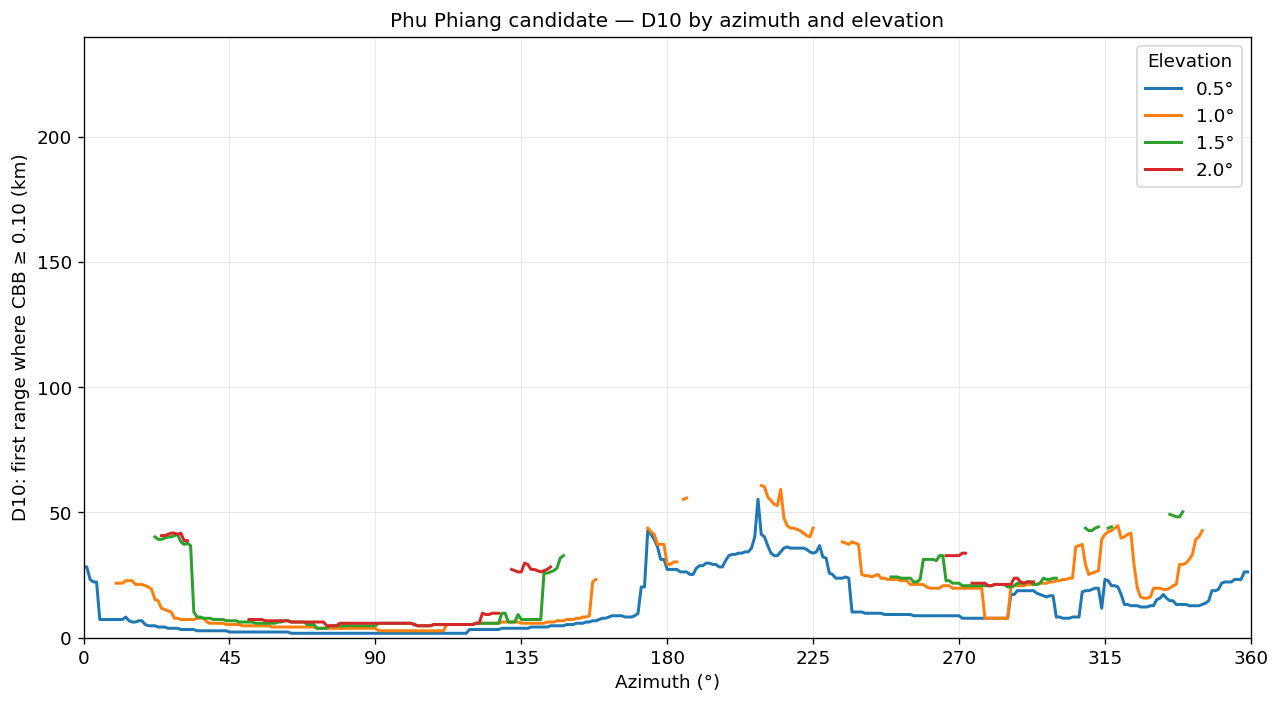

Saved: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/04_figures/Fig05_07_PhuPhiang_D10_by_Azimuth.png


In [16]:
# ============================================================
# STEP 16 — Figure 7: D10 by azimuth
# ============================================================

fig, ax = plt.subplots(figsize=(10.8, 6.0))

for elev in ELEVATIONS_DEG:
    sub = threshold_table[
        threshold_table["elevation_deg"] == elev
    ]

    ax.plot(
        sub["azimuth_deg"],
        sub["D10_km"],
        linewidth=1.8,
        label=f"{elev:.1f}°",
    )

ax.set_xlim(0, 359)
ax.set_ylim(0, 240)
ax.set_xticks(np.arange(0, 361, 45))
ax.set_xlabel("Azimuth (°)")
ax.set_ylabel("D10: first range where CBB ≥ 0.10 (km)")
ax.set_title(
    "Phu Phiang candidate — D10 by azimuth and elevation"
)
ax.grid(True, linewidth=0.4, alpha=0.4)
ax.legend(title="Elevation", loc="best")

fig.tight_layout()

fig7_path = (
    FIGURES_DIR /
    "Fig05_07_PhuPhiang_D10_by_Azimuth.png"
)

fig.savefig(
    fig7_path,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print("Saved:", fig7_path)

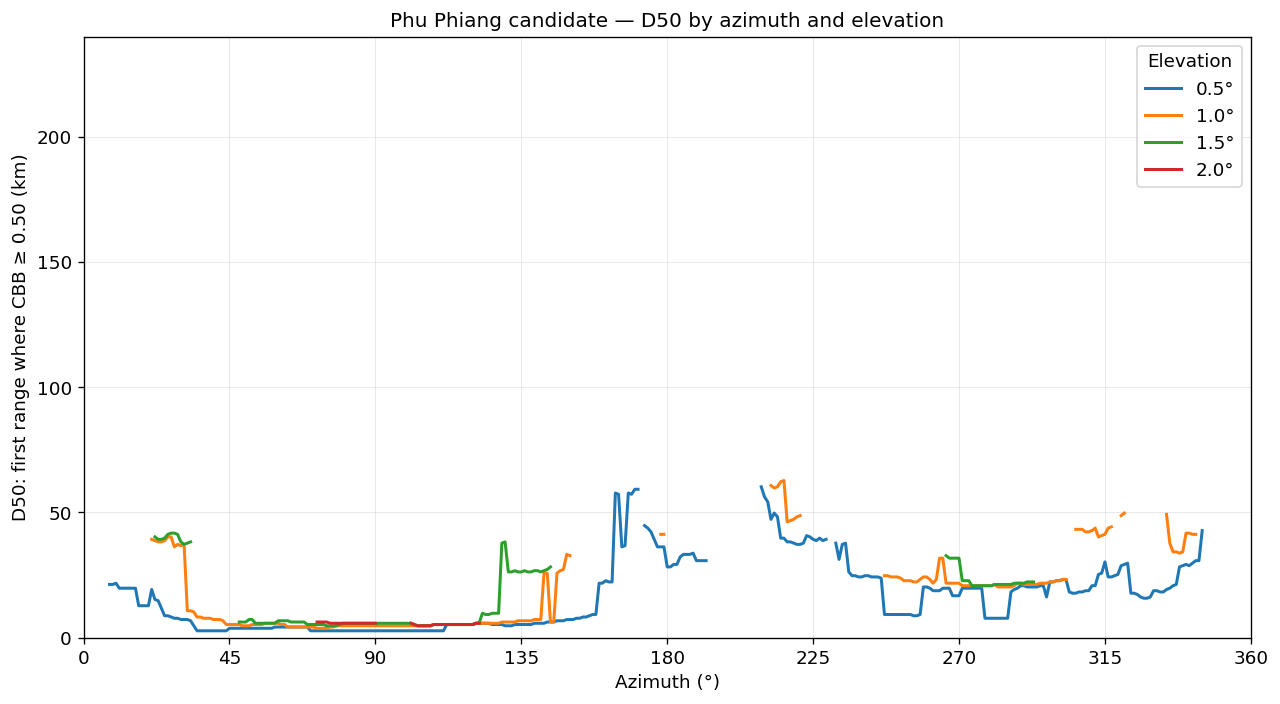

Saved: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/04_figures/Fig05_08_PhuPhiang_D50_by_Azimuth.png


In [17]:
# ============================================================
# STEP 17 — Figure 8: D50 by azimuth
# ============================================================

fig, ax = plt.subplots(figsize=(10.8, 6.0))

for elev in ELEVATIONS_DEG:
    sub = threshold_table[
        threshold_table["elevation_deg"] == elev
    ]

    ax.plot(
        sub["azimuth_deg"],
        sub["D50_km"],
        linewidth=1.8,
        label=f"{elev:.1f}°",
    )

ax.set_xlim(0, 359)
ax.set_ylim(0, 240)
ax.set_xticks(np.arange(0, 361, 45))
ax.set_xlabel("Azimuth (°)")
ax.set_ylabel("D50: first range where CBB ≥ 0.50 (km)")
ax.set_title(
    "Phu Phiang candidate — D50 by azimuth and elevation"
)
ax.grid(True, linewidth=0.4, alpha=0.4)
ax.legend(title="Elevation", loc="best")

fig.tight_layout()

fig8_path = (
    FIGURES_DIR /
    "Fig05_08_PhuPhiang_D50_by_Azimuth.png"
)

fig.savefig(
    fig8_path,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print("Saved:", fig8_path)

# Part H — Area-Weighted Coverage

## 13. Range Bands

แบ่งพื้นที่เป็น

$$
0-50,\;
50-100,\;
100-150,\;
150-200,\;
200-240\ \mathrm{km}
$$

แล้วคำนวณพื้นที่ Clear / Partial / Severe สำหรับแต่ละ elevation

In [18]:
# ============================================================
# STEP 18 — Polar gate area weights
# ============================================================

delta_az_rad = np.deg2rad(1.0)

annular_sector_area_m2 = (
    0.5
    * (
        RANGE_EDGES_M[1:]**2
        - RANGE_EDGES_M[:-1]**2
    )
    * delta_az_rad
)

area_weights_m2 = np.broadcast_to(
    annular_sector_area_m2[None, :],
    (NRAYS, NBINS),
)

print(
    "Total nominal polar area:",
    f"{area_weights_m2.sum()/1e6:,.1f} km²"
)
print(
    "Circle area πr²:",
    f"{np.pi*(MAX_RANGE_M/1000.0)**2:,.1f} km²"
)

Total nominal polar area: 180,955.7 km²
Circle area πr²: 180,955.7 km²


In [19]:
# ============================================================
# STEP 19 — Area-weighted blockage by range band
# ============================================================

range_bands = [
    (0, 50),
    (50, 100),
    (100, 150),
    (150, 200),
    (200, 240),
]

area_rows = []

for elev in ELEVATIONS_DEG:
    cbb = multi[float(elev)]["cbb"]
    valid = np.isfinite(cbb)

    for r0, r1 in range_bands:
        in_band_1d = (
            (RANGE_CENTERS_KM >= r0)
            & (RANGE_CENTERS_KM < r1)
        )

        in_band = np.broadcast_to(
            in_band_1d[None, :],
            (NRAYS, NBINS),
        )

        mask = valid & in_band

        total_area = float(
            area_weights_m2[mask].sum()
        )

        clear = mask & (cbb < CLEAR_THRESHOLD)
        partial = (
            mask
            & (cbb >= CLEAR_THRESHOLD)
            & (cbb < SEVERE_THRESHOLD)
        )
        severe = mask & (cbb >= SEVERE_THRESHOLD)

        area_rows.append({
            "elevation_deg": elev,
            "range_band_km": f"{r0}-{r1}",
            "valid_area_km2": total_area / 1e6,
            "clear_area_pct": (
                100.0 * area_weights_m2[clear].sum() / total_area
            ),
            "partial_area_pct": (
                100.0 * area_weights_m2[partial].sum() / total_area
            ),
            "severe_area_pct": (
                100.0 * area_weights_m2[severe].sum() / total_area
            ),
        })

area_summary = pd.DataFrame(area_rows)

display(
    area_summary.style.format({
        "elevation_deg": "{:.1f}",
        "valid_area_km2": "{:,.1f}",
        "clear_area_pct": "{:.2f}",
        "partial_area_pct": "{:.2f}",
        "severe_area_pct": "{:.2f}",
    })
)

area_csv = (
    TABLES_DIR /
    "05_PhuPhiang_AreaWeighted_Blockage_by_RangeBand.csv"
)

area_summary.to_csv(
    area_csv,
    index=False,
)

print("\nSaved:")
print(area_csv)

,elevation_deg,range_band_km,valid_area_km2,clear_area_pct,partial_area_pct,severe_area_pct
0,0.5,0-50,"7,854.0",10.70,16.09,73.20
1,0.5,50-100,"23,561.9",0.02,11.26,88.72
2,0.5,100-150,"39,269.9",0.00,10.83,89.17
3,0.5,150-200,"54,977.9",0.00,10.83,89.17
4,0.5,200-240,"55,292.0",0.00,10.83,89.17
5,1.0,0-50,"7,854.0",34.98,16.37,48.64
6,1.0,50-100,"23,561.9",19.67,18.33,62.00
7,1.0,100-150,"39,269.9",19.44,18.33,62.22
8,1.0,150-200,"54,977.9",19.44,18.33,62.22
9,1.0,200-240,"55,292.0",19.44,18.33,62.22



Saved:
/content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/05_tables/05_PhuPhiang_AreaWeighted_Blockage_by_RangeBand.csv


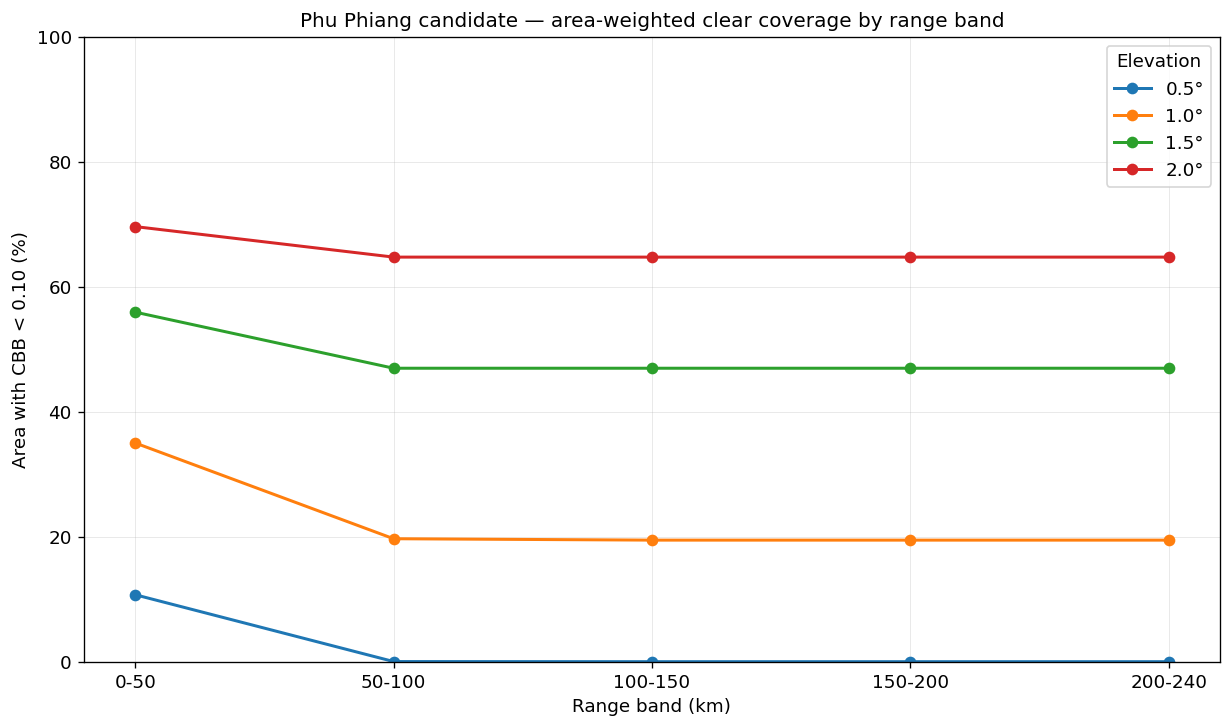

Saved: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/04_figures/Fig05_09_PhuPhiang_ClearArea_by_RangeBand.png


In [20]:
# ============================================================
# STEP 20 — Figure 9: clear area by range band
# ============================================================

fig, ax = plt.subplots(figsize=(10.4, 6.2))

for elev in ELEVATIONS_DEG:
    sub = area_summary[
        area_summary["elevation_deg"] == elev
    ]

    ax.plot(
        sub["range_band_km"],
        sub["clear_area_pct"],
        marker="o",
        linewidth=1.8,
        label=f"{elev:.1f}°",
    )

ax.set_ylim(0, 100)
ax.set_xlabel("Range band (km)")
ax.set_ylabel("Area with CBB < 0.10 (%)")
ax.set_title(
    "Phu Phiang candidate — area-weighted clear coverage by range band"
)
ax.grid(True, linewidth=0.4, alpha=0.4)
ax.legend(title="Elevation", loc="best")

fig.tight_layout()

fig9_path = (
    FIGURES_DIR /
    "Fig05_09_PhuPhiang_ClearArea_by_RangeBand.png"
)

fig.savefig(
    fig9_path,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print("Saved:", fig9_path)

In [21]:
# ============================================================
# STEP 21 — Overall area-weighted summary
# ============================================================

overall_rows = []

for elev in ELEVATIONS_DEG:
    cbb = multi[float(elev)]["cbb"]
    valid = np.isfinite(cbb)

    total_area = float(
        area_weights_m2[valid].sum()
    )

    clear = valid & (cbb < CLEAR_THRESHOLD)
    partial = (
        valid
        & (cbb >= CLEAR_THRESHOLD)
        & (cbb < SEVERE_THRESHOLD)
    )
    severe = valid & (cbb >= SEVERE_THRESHOLD)

    overall_rows.append({
        "elevation_deg": elev,
        "clear_area_pct_0_240km": (
            100.0 * area_weights_m2[clear].sum() / total_area
        ),
        "partial_area_pct_0_240km": (
            100.0 * area_weights_m2[partial].sum() / total_area
        ),
        "severe_area_pct_0_240km": (
            100.0 * area_weights_m2[severe].sum() / total_area
        ),
        "mean_cbb_gate_based": float(np.nanmean(cbb)),
        "median_cbb_gate_based": float(np.nanmedian(cbb)),
    })

overall_summary = pd.DataFrame(overall_rows)

display(
    overall_summary.style.format({
        "elevation_deg": "{:.1f}",
        "clear_area_pct_0_240km": "{:.2f}",
        "partial_area_pct_0_240km": "{:.2f}",
        "severe_area_pct_0_240km": "{:.2f}",
        "mean_cbb_gate_based": "{:.3f}",
        "median_cbb_gate_based": "{:.3f}",
    })
)

overall_csv = (
    TABLES_DIR /
    "05_PhuPhiang_Overall_MultiElevation_Coverage.csv"
)

overall_summary.to_csv(
    overall_csv,
    index=False,
)

print("\nSaved:")
print(overall_csv)

,elevation_deg,clear_area_pct_0_240km,partial_area_pct_0_240km,severe_area_pct_0_240km,mean_cbb_gate_based,median_cbb_gate_based
0,0.5,0.47,11.12,88.42,0.813,1.000
1,1.0,20.15,18.25,61.60,0.579,0.682
2,1.5,47.33,14.85,37.82,0.366,0.090
3,2.0,64.93,23.41,11.65,0.152,0.000



Saved:
/content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/05_tables/05_PhuPhiang_Overall_MultiElevation_Coverage.csv


# Part I — Difference Maps

## 14. CBB Difference Relative to 0.5°

กำหนด

$$
\Delta CBB_{\theta-0.5}
=
CBB_{\theta}
-
CBB_{0.5^\circ}
$$

หาก $\Delta CBB<0$ หมายถึง elevation ที่สูงขึ้นมี blockage ต่ำกว่า 0.5°

Difference map ใช้ diverging colormap เพราะมีทั้งค่าบวกและลบ และไม่ใช่ absolute PBB/CBB product

/tmp/ipykernel_624/3641378077.py:26: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  m = ax.pcolormesh(


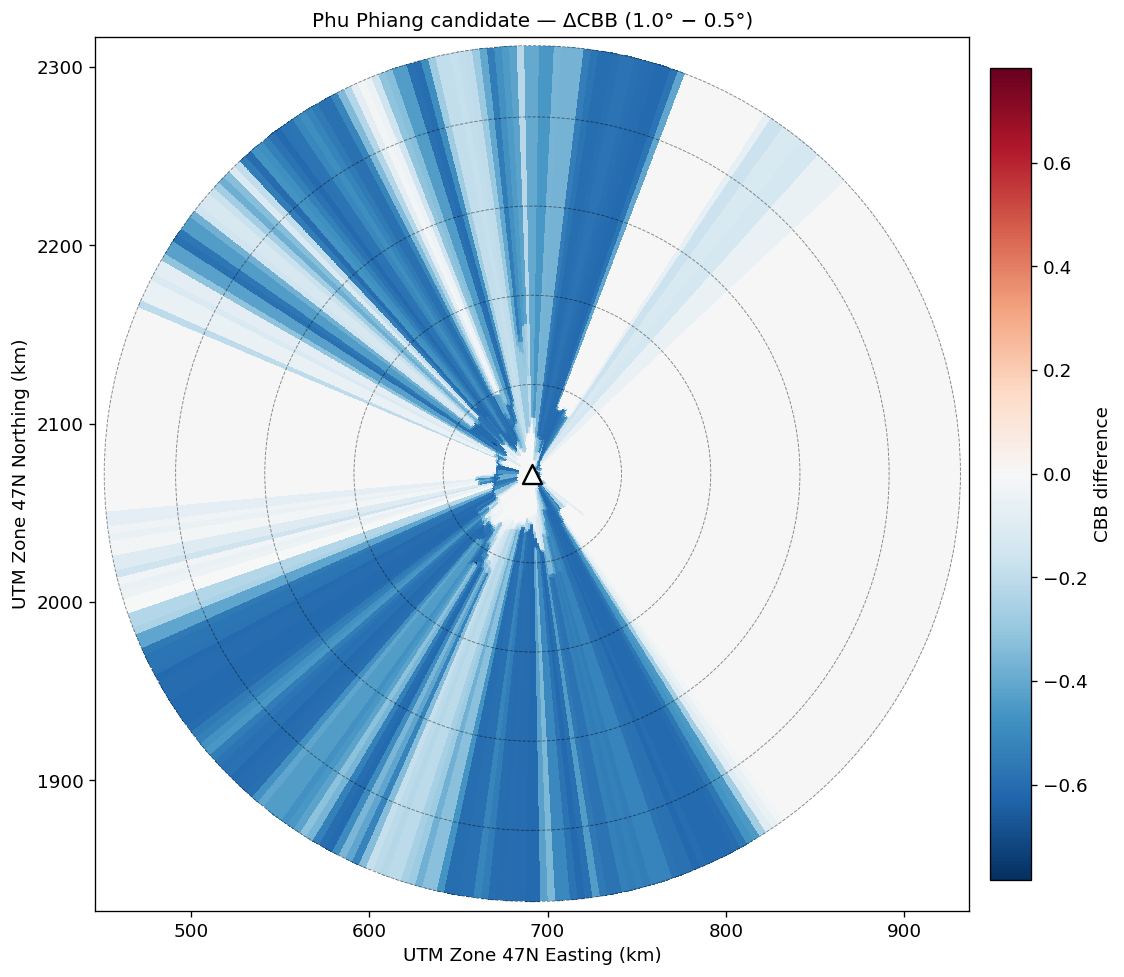

Saved: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/04_figures/Fig05_10_PhuPhiang_DeltaCBB_1p0_minus_0p5deg.png


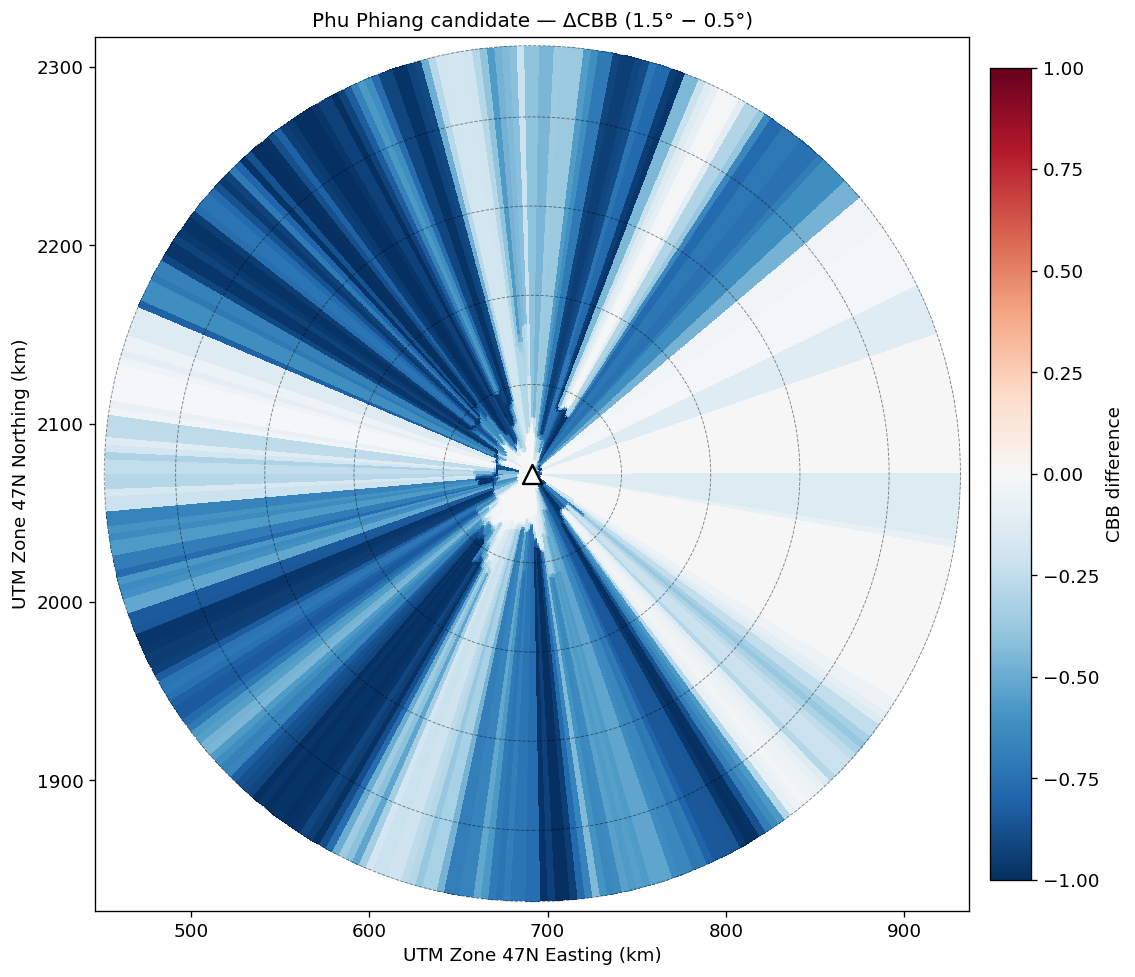

Saved: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/04_figures/Fig05_11_PhuPhiang_DeltaCBB_1p5_minus_0p5deg.png


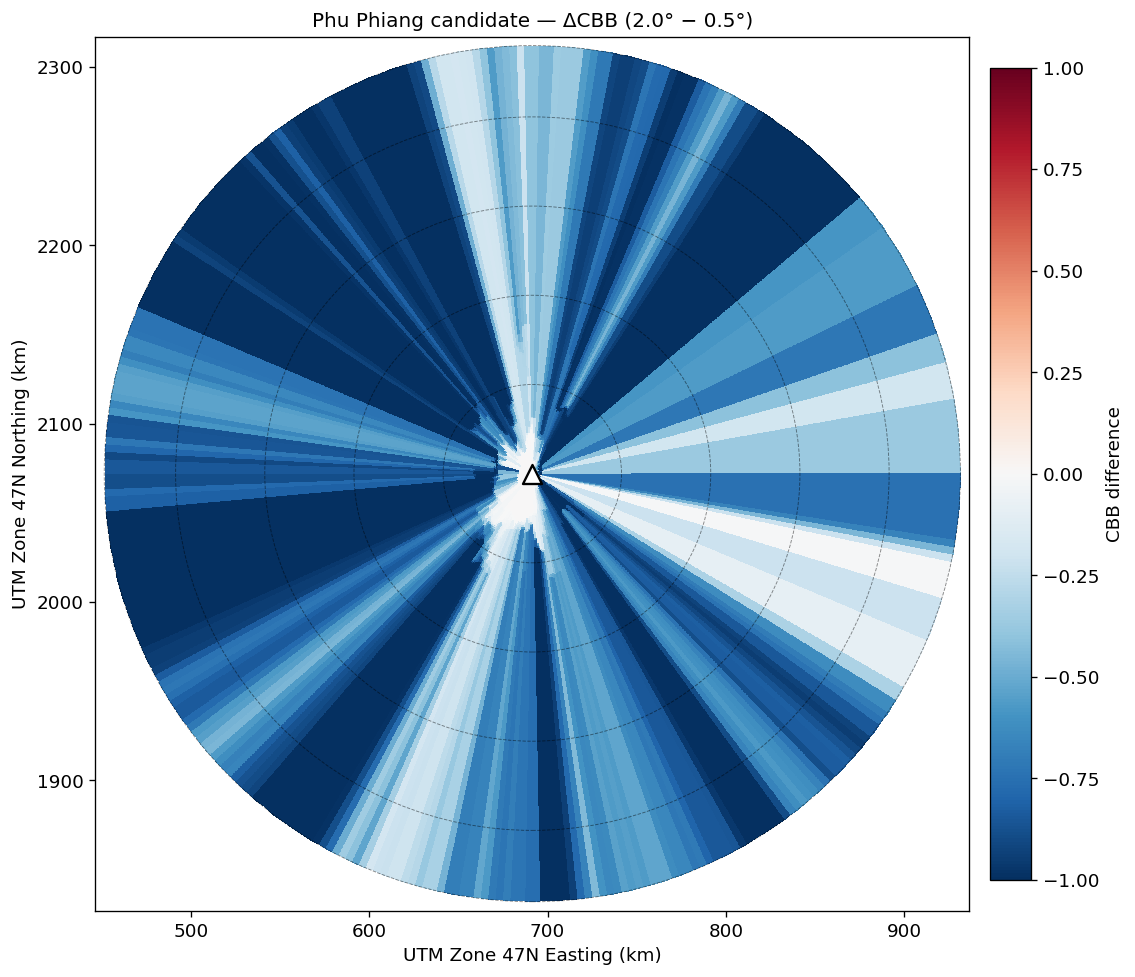

Saved: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/04_figures/Fig05_12_PhuPhiang_DeltaCBB_2p0_minus_0p5deg.png


In [22]:
# ============================================================
# STEP 22 — Figures 10–12: ΔCBB relative to 0.5°
# ============================================================

reference = multi[0.5]
diff_paths = []

for fig_number, elev in enumerate([1.0, 1.5, 2.0], start=10):
    item = multi[float(elev)]

    diff = item["cbb"] - reference["cbb"]

    max_abs = float(
        np.nanmax(np.abs(diff))
    )
    max_abs = max(max_abs, 0.05)

    norm = TwoSlopeNorm(
        vmin=-max_abs,
        vcenter=0.0,
        vmax=max_abs,
    )

    fig, ax = plt.subplots(figsize=(9.8, 8.8))

    m = ax.pcolormesh(
        reference["x_m"] / 1000.0,
        reference["y_m"] / 1000.0,
        diff,
        cmap="RdBu_r",
        norm=norm,
        shading="auto",
    )

    for rr in [50, 100, 150, 200, 240]:
        ax.add_patch(
            Circle(
                (site_x_km, site_y_km),
                rr,
                fill=False,
                linestyle="--",
                linewidth=0.55,
                edgecolor="black",
                alpha=0.45,
            )
        )

    ax.scatter(
        site_x_km,
        site_y_km,
        marker=CANDIDATE_MARKER,
        s=130,
        facecolor=CANDIDATE_FACE,
        edgecolor=CANDIDATE_EDGE,
        linewidth=1.4,
        zorder=7,
    )

    ax.set_xlim(site_x_km - 245, site_x_km + 245)
    ax.set_ylim(site_y_km - 245, site_y_km + 245)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("UTM Zone 47N Easting (km)")
    ax.set_ylabel("UTM Zone 47N Northing (km)")
    ax.set_title(
        f"Phu Phiang candidate — ΔCBB ({elev:.1f}° − 0.5°)"
    )

    cbar = fig.colorbar(
        m,
        ax=ax,
        shrink=0.82,
        pad=0.02,
    )
    cbar.set_label("CBB difference")

    fig.tight_layout()

    elev_tag = str(elev).replace(".", "p")
    path = (
        FIGURES_DIR /
        f"Fig05_{fig_number:02d}_"
        f"PhuPhiang_DeltaCBB_{elev_tag}_minus_0p5deg.png"
    )

    fig.savefig(
        path,
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

    diff_paths.append(str(path))
    print("Saved:", path)

# Part J — Minimum Usable Elevation

## 15. MUE

ตรวจ elevations จากต่ำไปสูง แล้วเลือกค่าต่ำที่สุดที่

$$
CBB<0.10
$$

หากไม่มี elevation ใดผ่านเกณฑ์ภายในชุด 0.5–2.0° จะจัดเป็น **not clear within tested elevations**

In [23]:
# ============================================================
# STEP 23 — Compute Minimum Usable Elevation
# ============================================================

cbb_stack = np.stack(
    [
        multi[float(elev)]["cbb"]
        for elev in ELEVATIONS_DEG
    ],
    axis=0,
)

clear_stack = (
    np.isfinite(cbb_stack)
    & (cbb_stack < CLEAR_THRESHOLD)
)

mue = np.full(
    (NRAYS, NBINS),
    np.nan,
    dtype=np.float32,
)

for elev_index, elev in enumerate(ELEVATIONS_DEG):
    assign = (
        np.isnan(mue)
        & clear_stack[elev_index]
    )
    mue[assign] = elev

never_clear = np.isnan(mue)

print(
    "Never clear within tested elevations:",
    f"{100*never_clear.mean():.2f}% of polar gates"
)

for elev in ELEVATIONS_DEG:
    print(
        f"MUE = {elev:.1f}°:",
        f"{100*np.mean(mue == elev):.2f}%"
    )

Never clear within tested elevations: 33.16% of polar gates
MUE = 0.5°: 5.03%
MUE = 1.0°: 20.21%
MUE = 1.5°: 25.21%
MUE = 2.0°: 16.40%


/tmp/ipykernel_624/1714824319.py:21: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  m = ax.pcolormesh(


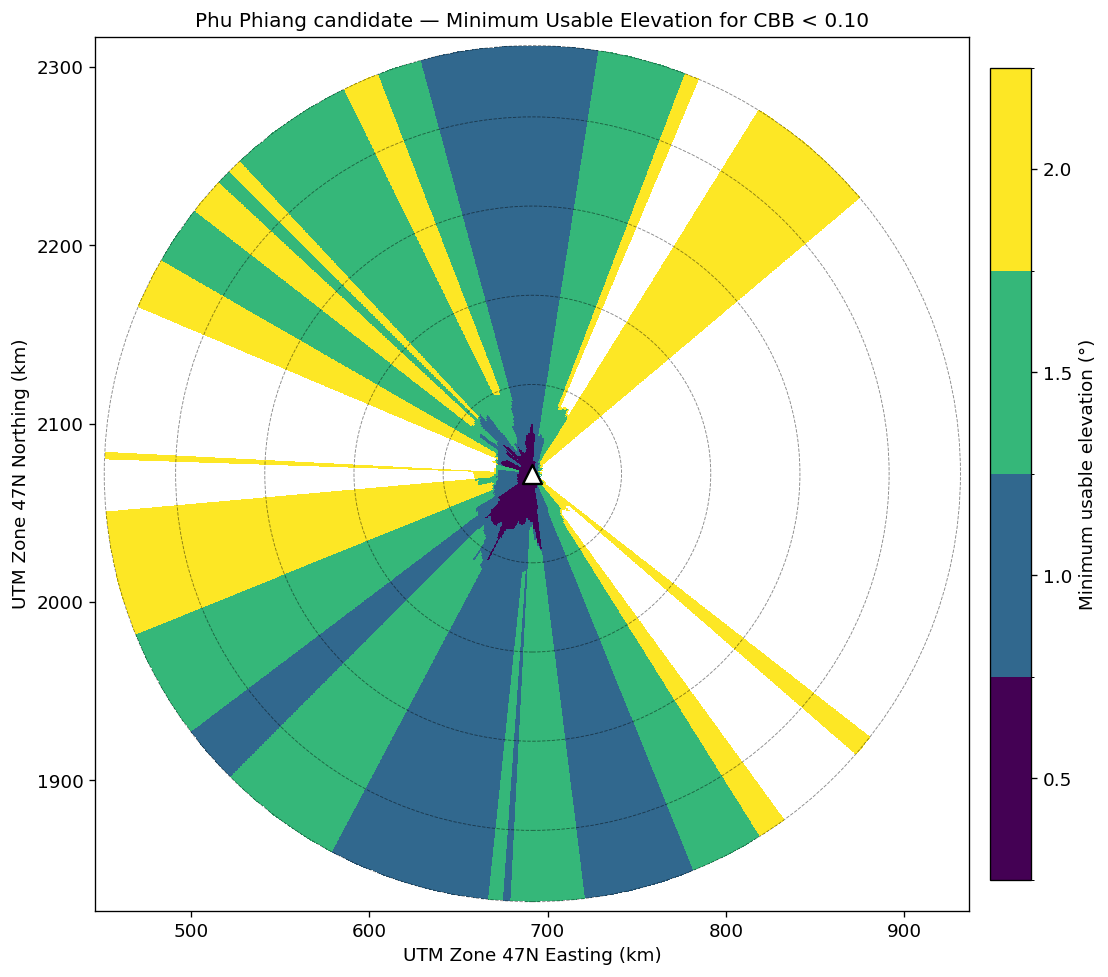

Saved: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/04_figures/Fig05_13_PhuPhiang_Minimum_Usable_Elevation.png


In [24]:
# ============================================================
# STEP 24 — Figure 13: Minimum Usable Elevation map
# ============================================================

reference_xy = multi[0.5]
mue_plot = np.ma.masked_invalid(mue)

levels = [0.25, 0.75, 1.25, 1.75, 2.25]

cmap_mue = mpl.colormaps["viridis"].resampled(
    len(ELEVATIONS_DEG)
)

norm_mue = mpl.colors.BoundaryNorm(
    levels,
    cmap_mue.N,
)

fig, ax = plt.subplots(figsize=(9.8, 8.8))

m = ax.pcolormesh(
    reference_xy["x_m"] / 1000.0,
    reference_xy["y_m"] / 1000.0,
    mue_plot,
    cmap=cmap_mue,
    norm=norm_mue,
    shading="auto",
)

for rr in [50, 100, 150, 200, 240]:
    ax.add_patch(
        Circle(
            (site_x_km, site_y_km),
            rr,
            fill=False,
            linestyle="--",
            linewidth=0.55,
            edgecolor="black",
            alpha=0.45,
        )
    )

ax.scatter(
    site_x_km,
    site_y_km,
    marker=CANDIDATE_MARKER,
    s=130,
    facecolor=CANDIDATE_FACE,
    edgecolor=CANDIDATE_EDGE,
    linewidth=1.4,
    zorder=7,
)

ax.set_xlim(site_x_km - 245, site_x_km + 245)
ax.set_ylim(site_y_km - 245, site_y_km + 245)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("UTM Zone 47N Easting (km)")
ax.set_ylabel("UTM Zone 47N Northing (km)")
ax.set_title(
    "Phu Phiang candidate — Minimum Usable Elevation for CBB < 0.10"
)

cbar = fig.colorbar(
    m,
    ax=ax,
    shrink=0.82,
    pad=0.02,
    ticks=ELEVATIONS_DEG,
)
cbar.set_label("Minimum usable elevation (°)")

fig.tight_layout()

fig13_path = (
    FIGURES_DIR /
    "Fig05_13_PhuPhiang_Minimum_Usable_Elevation.png"
)

fig.savefig(
    fig13_path,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print("Saved:", fig13_path)

In [25]:
# ============================================================
# STEP 25 — MUE area-weighted summary
# ============================================================

valid_any = np.isfinite(cbb_stack).any(axis=0)

total_area = float(
    area_weights_m2[valid_any].sum()
)

mue_rows = []

for elev in ELEVATIONS_DEG:
    mask = (
        valid_any
        & (mue == elev)
    )

    area = float(
        area_weights_m2[mask].sum()
    )

    mue_rows.append({
        "MUE_class": f"{elev:.1f}°",
        "area_km2": area / 1e6,
        "area_pct": 100.0 * area / total_area,
    })

mask_never = (
    valid_any
    & np.isnan(mue)
)

area_never = float(
    area_weights_m2[mask_never].sum()
)

mue_rows.append({
    "MUE_class": "Not clear at 0.5–2.0°",
    "area_km2": area_never / 1e6,
    "area_pct": 100.0 * area_never / total_area,
})

mue_summary = pd.DataFrame(mue_rows)

display(
    mue_summary.style.format({
        "area_km2": "{:,.1f}",
        "area_pct": "{:.2f}",
    })
)

mue_csv = (
    TABLES_DIR /
    "05_PhuPhiang_Minimum_Usable_Elevation_AreaSummary.csv"
)

mue_summary.to_csv(
    mue_csv,
    index=False,
)

print("\nSaved:")
print(mue_csv)

,MUE_class,area_km2,area_pct
0,0.5°,845.3,0.47
1,1.0°,"35,613.4",19.68
2,1.5°,"49,194.7",27.19
3,2.0°,"31,848.6",17.60
4,Not clear at 0.5–2.0°,"63,453.7",35.07



Saved:
/content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/05_tables/05_PhuPhiang_Minimum_Usable_Elevation_AreaSummary.csv


# Part K — การตีความ

## 16. สิ่งที่ควรพิจารณาพร้อมกัน

Elevation ที่สูงขึ้นอาจทำให้

- CBB ลดลง
- D10/D50 เลื่อนไปไกลขึ้น
- clear-area percentage เพิ่มขึ้น

แต่ในเวลาเดียวกัน beam altitude ที่ระยะไกลก็เพิ่มขึ้น

ดังนั้นการประเมิน radar coverage ควรพิจารณา

$$
\boxed{
\mathrm{Terrain\ visibility}
+
\mathrm{Beam\ sampling\ altitude}
}
$$

พร้อมกัน

## 17. แบบฝึกคิด

### CORE

1. elevation ใดให้ clear-area percentage สูงที่สุดใน 0–50 km?
2. elevation ใดให้ severe-area percentageต่ำที่สุดใน 0–240 km?
3. sector ใดต้องใช้ MUE สูงกว่า 1.0°?
4. ที่ 200 km beam centre ของ 0.5° และ 2.0° ต่างกันกี่ metre?

### ADVANCED

5. เปรียบเทียบ D50 ของ 0.5° กับ 1.0°
6. หา sector ที่การยก elevation ช่วยลด CBB มากที่สุด
7. อธิบายข้อดีของ area-weighted statistics เมื่อเทียบกับ gate count

### RESEARCH EXTENSION

8. ออกแบบ metric ที่รวม terrain visibility กับ beam altitude
9. ถ้าภารกิจหลักคือ QPE ภายใน 100 km ควรให้น้ำหนัก elevation trade-off อย่างไร?
10. อธิบายว่าทำไม MUE ควรประเมินซ้ำเมื่อเปลี่ยน DEM resolution หรือ antenna height

In [26]:
# ============================================================
# STEP 26 — Save multi-elevation arrays
# ============================================================

array_output = (
    RESULTS_DIR /
    "05_PhuPhiang_MultiElevation_PBB_CBB_360x480.npz"
)

np.savez_compressed(
    array_output,
    site_id=FOCUS_SITE_ID,
    site_name=FOCUS_SITE_NAME,
    elevations_deg=ELEVATIONS_DEG,
    azimuth_deg=AZIMUTHS_DEG,
    range_centers_m=RANGE_CENTERS_M,
    beam_radius_m=beam_radius_m,
    cbb_0p5=multi[0.5]["cbb"],
    cbb_1p0=multi[1.0]["cbb"],
    cbb_1p5=multi[1.5]["cbb"],
    cbb_2p0=multi[2.0]["cbb"],
    pbb_0p5=multi[0.5]["pbb"],
    pbb_1p0=multi[1.0]["pbb"],
    pbb_1p5=multi[1.5]["pbb"],
    pbb_2p0=multi[2.0]["pbb"],
    x_0p5_m=multi[0.5]["x_m"],
    y_0p5_m=multi[0.5]["y_m"],
    minimum_usable_elevation_deg=mue,
)

print("Saved:")
print(array_output)
print(
    "File size:",
    f"{array_output.stat().st_size/1024**2:.2f} MB"
)

Saved:
/content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/03_results/05_PhuPhiang_MultiElevation_PBB_CBB_360x480.npz
File size: 1.26 MB


In [27]:
# ============================================================
# STEP 27 — Save metadata and final readiness check
# ============================================================

metadata = {
    "study_site_selection_method": (
        "Unique site_name containing 'Phu Phiang'"
    ),
    "site_id": FOCUS_SITE_ID,
    "site_name": FOCUS_SITE_NAME,
    "ground_elevation_msl_m": RADAR_GROUND_MSL_M,
    "antenna_agl_teaching_assumption_m": ANTENNA_AGL_M,
    "radar_altitude_msl_m": RADAR_ALTITUDE_MSL_M,
    "elevation_angles_deg": ELEVATIONS_DEG.tolist(),
    "beamwidth_deg": BEAMWIDTH_DEG,
    "k_factor": K_STANDARD,
    "earth_radius_m": EARTH_RADIUS_M,
    "nrays": NRAYS,
    "nbins": NBINS,
    "range_resolution_m": RANGE_RES_M,
    "maximum_range_km": MAX_RANGE_M / 1000.0,
    "clear_threshold": CLEAR_THRESHOLD,
    "severe_threshold": SEVERE_THRESHOLD,
    "area_weighting": (
        "Planar annular-sector area using nominal range-bin edges "
        "and 1-degree azimuth spacing"
    ),
    "mue_definition": (
        "Lowest tested elevation with CBB < 0.10 at common "
        "azimuth/range index"
    ),
    "mue_visual_reference_coordinates": (
        "0.5-degree projected gate coordinates"
    ),
    "wradlib_version": wrl.__version__,
    "dem_path": str(DEM_PATH),
    "multi_elevation_array": str(array_output),
    "threshold_table": str(threshold_csv),
    "area_summary_table": str(area_csv),
    "overall_summary_table": str(overall_csv),
    "beam_altitude_table": str(beam_altitude_csv),
    "mue_summary_table": str(mue_csv),
}

metadata_path = (
    METADATA_DIR /
    "05_PhuPhiang_MultiElevation_Metadata.json"
)

with open(
    metadata_path,
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        metadata,
        f,
        indent=2,
        ensure_ascii=False,
    )

all_cbb_in_range = all(
    (
        np.nanmin(multi[float(e)]["cbb"]) >= 0.0
        and np.nanmax(multi[float(e)]["cbb"]) <= 1.0
    )
    for e in ELEVATIONS_DEG
)

all_valid = all(
    (
        1.0 - multi[float(e)]["missing"].mean()
    ) >= 0.99
    for e in ELEVATIONS_DEG
)

all_monotonic = bool(
    qc_table["cbb_monotonic_complete_rays"].all()
)

final_checks = {
    "Phu Phiang site uniquely resolved": len(match) == 1,
    "All 4 elevations calculated": len(multi) == 4,
    "≥99% terrain valid at every elevation": all_valid,
    "All CBB values within 0–1": all_cbb_in_range,
    "CBB monotonic along complete rays": all_monotonic,
    "D10/D50 table saved": threshold_csv.exists(),
    "Area-weighted summary saved": area_csv.exists(),
    "Overall summary saved": overall_csv.exists(),
    "Beam-altitude table saved": beam_altitude_csv.exists(),
    "MUE summary saved": mue_csv.exists(),
    "Multi-elevation NPZ saved": array_output.exists(),
    "Metadata JSON saved": metadata_path.exists(),
}

print("=" * 86)
print("NOTEBOOK 05 — FINAL READINESS CHECK")
print("=" * 86)

all_ok = True

for label, status in final_checks.items():
    print(("✓" if status else "✗"), label)
    all_ok = all_ok and status

print("=" * 86)

print("\nKey outputs")
print("-----------")
print("Arrays         :", array_output)
print("D10/D50        :", threshold_csv)
print("Area summary   :", area_csv)
print("Overall summary:", overall_csv)
print("MUE summary    :", mue_csv)
print("Metadata       :", metadata_path)

if all_ok:
    print(
        "\n✓ MULTI-ELEVATION ANALYSIS READY — proceed to "
        "Notebook 06 for multi-site comparison."
    )
else:
    raise RuntimeError(
        "One or more Notebook 05 QC checks failed."
    )

NOTEBOOK 05 — FINAL READINESS CHECK
✓ Phu Phiang site uniquely resolved
✓ All 4 elevations calculated
✓ ≥99% terrain valid at every elevation
✓ All CBB values within 0–1
✓ CBB monotonic along complete rays
✓ D10/D50 table saved
✓ Area-weighted summary saved
✓ Overall summary saved
✓ Beam-altitude table saved
✓ MUE summary saved
✓ Multi-elevation NPZ saved
✓ Metadata JSON saved

Key outputs
-----------
Arrays         : /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/03_results/05_PhuPhiang_MultiElevation_PBB_CBB_360x480.npz
D10/D50        : /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/05_tables/05_PhuPhiang_D10_D50_All_Azimuths.csv
Area summary   : /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/05_tables/05_PhuPhiang_AreaWeighted_Blockage_by_RangeBand.csv
Overall summary: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/05_tables/05_PhuPhiang_Overall_MultiElevation_Coverage.csv
MUE summary    : /content/drive/MyDrive/Teaching_Radar_Terrain_

# 18. สรุปบทเรียน

Notebook นี้ทดสอบ elevation effect แบบ controlled experiment:

$$
0.5^\circ
\rightarrow
1.0^\circ
\rightarrow
1.5^\circ
\rightarrow
2.0^\circ
$$

และวิเคราะห์

$$
CBB(\alpha,r,\theta)
$$

$$
D_{10}(\alpha,\theta)
$$

$$
D_{50}(\alpha,\theta)
$$

$$
\mathrm{Clear\ area}(\theta,\mathrm{range\ band})
$$

รวมถึง

$$
MUE(\alpha,r)
$$

### Output หลัก

```text
03_results/
└── 05_PhuPhiang_MultiElevation_PBB_CBB_360x480.npz

05_tables/
├── 05_PhuPhiang_Beam_Altitude_Selected_Ranges.csv
├── 05_PhuPhiang_D10_D50_All_Azimuths.csv
├── 05_PhuPhiang_AreaWeighted_Blockage_by_RangeBand.csv
├── 05_PhuPhiang_Overall_MultiElevation_Coverage.csv
└── 05_PhuPhiang_Minimum_Usable_Elevation_AreaSummary.csv

02_metadata/
└── 05_PhuPhiang_MultiElevation_Metadata.json
```

---

## Next — Notebook 06

บทถัดไปจะเปลี่ยนตัวแปรจาก **elevation** เป็น **site** แล้วเปรียบเทียบ Current Tha Wang Pha กับ candidate sites ทั้งหมด ภายใต้ geometry เดียวกัน เพื่อทดสอบเชิงปริมาณว่าตำแหน่งภูเพียงให้ low-elevation terrain visibility ดีกว่าสถานีปัจจุบันเพียงใด